In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd
import os

In [13]:
# Data path from AGENTS.md
data_folder = "/content/data/extracted/"

# Model identifier and Google Drive output directory
model_name = "LSTM_forecast_15m_1h_2017_2019_data"
output_folder = os.path.join(
    "/content/drive/MyDrive/solar_data", "model_output", model_name
)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:   ", data_folder)
print("output_folder: ", output_folder)
print("trainval_pv:   ", trainval_pv_path)
print("test_pv:       ", test_pv_path)
print("times_trainval:", times_trainval_path)
print("times_test:    ", times_test_path)

data_folder:    /content/data/extracted/
output_folder:  /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data
trainval_pv:    /content/data/extracted/trainval_pv_log.npy
test_pv:        /content/data/extracted/test_pv_log.npy
times_trainval: /content/data/extracted/times_trainval.npy
times_test:     /content/data/extracted/times_test.npy


In [14]:
# Model & Forecast Horizon Parameters
# SEQ_LEN: Number of historical 1-minute time steps used as input (16 minutes)
SEQ_LEN = 16

# Stanford Solar Forecasting Dataset is logged at 1-minute intervals.
HORIZON_MAP = {
    "15min": 15,
    "1hour": 60,
}

FORECAST_HORIZONS = [15, 60]
HORIZON_NAMES = ["15 min", "1 hour"]
NUM_TARGETS = len(FORECAST_HORIZONS)

# Training hyper-parameters
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

print(f"Sequence Length (History Window): {SEQ_LEN} minutes")
print(f"Target Horizons:                  {FORECAST_HORIZONS} steps ({HORIZON_NAMES})")
print(f"Number of Target Outputs:         {NUM_TARGETS}")
print(f"Cross-Validation Folds:           {NUM_FOLDS}")

Sequence Length (History Window): 16 minutes
Target Horizons:                  [15, 60] steps (['15 min', '1 hour'])
Number of Target Outputs:         2
Cross-Validation Folds:           10


In [15]:
trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(f"trainval_pv shape: {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:     {test_pv.shape} | times: {times_test.shape}")

trainval_pv shape: (349372,) | times: (349372,)
test_pv shape:     (14003,) | times: (14003,)


In [16]:
def create_day_aware_forecast_sequences(
    pv_array, times_array, seq_len=16, horizons=[15, 60], allow_partial=False
):
    """
    Constructs (X, y, sequence_dates, sequence_times) sequences
    ensuring that no sequence crosses overnight boundaries or
    distinct calendar dates.

    Parameters:
        pv_array: 1D numpy array of PV power generation values (kW)
        times_array: 1D numpy array of timestamps (datetime objects)
        seq_len: Number of historical lag steps for input X
        horizons: List/tuple of forecast steps ahead [15, 60]
        allow_partial: If True, generates sequences all the way to sunset
                       (cutoff at min(horizons) instead of max(horizons)).
                       Horizons that exceed sunset are padded with NaN / None.
                       This allows 15m and 1h forecasts to run through the entire afternoon!

    Returns:
        X: Array of shape (N, seq_len, 1)
        y: Array of shape (N, len(horizons)) [or (N,) if single horizon]
        valid_dates: Array of base calendar dates (N,)
        valid_times: Array of target forecast timestamps (N, len(horizons))
    """
    is_multi = isinstance(horizons, (list, tuple, np.ndarray))
    if is_multi:
        horizon_list = list(horizons)
        max_horizon = max(horizon_list)
        min_horizon = min(horizon_list)
    else:
        horizon_list = [horizons]
        max_horizon = horizons
        min_horizon = horizons

    cutoff_horizon = min_horizon if allow_partial else max_horizon

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    X_list, y_list = [], []
    valid_dates_list = []
    valid_times_list = []

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Skip days that do not have enough points for sequence + cutoff horizon
        if num_day_points <= seq_len + cutoff_horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - cutoff_horizon):
            seq_x = day_pv[i - seq_len : i]

            if is_multi:
                seq_y = []
                target_times = []
                for h in horizon_list:
                    if i + h < num_day_points:
                        seq_y.append(day_pv[i + h])
                        target_times.append(day_times[i + h])
                    else:
                        seq_y.append(np.nan)
                        target_times.append(None)
            else:
                seq_y = day_pv[i + horizon_list[0]]
                target_times = day_times[i + horizon_list[0]]

            X_list.append(seq_x)
            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(target_times)

    X = np.expand_dims(
        np.array(X_list, dtype=np.float32), axis=-1
    )  # Shape: (N, seq_len, 1)

    y = np.array(y_list, dtype=np.float32)  # Shape: (N, num_horizons) or (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list, dtype=object)

    return X, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_forecast_sequences(
        trainval_pv, times_trainval, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS
    )
)

# Set allow_partial=True for test set so 15m and 1h forecasts continue all the way to sunset!
X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_forecast_sequences(
    test_pv, times_test, seq_len=SEQ_LEN, horizons=FORECAST_HORIZONS, allow_partial=True
)

print(f"X_trainval shape: {X_trainval.shape}, y_trainval shape: {y_trainval.shape}")
print(f"X_test shape:     {X_test.shape}, y_test shape:     {y_test.shape}")
print(
    f"dates_trainval:   {dates_trainval_seq.shape}, times_trainval: {times_trainval_seq.shape}"
)
print(
    f"dates_test:       {dates_test_seq.shape}, times_test:       {times_test_seq.shape}"
)

X_trainval shape: (311600, 16, 1), y_trainval shape: (311600, 2)
X_test shape:     (13383, 16, 1), y_test shape:     (13383, 2)
dates_trainval:   (311600,), times_trainval: (311600, 2)
dates_test:       (13383,), times_test:       (13383, 2)


In [ ]:
def day_block_shuffle_indices(dates_array, seed=1):
    """
    Returns the unique calendar dates in a shuffled order.
    (Renamed conceptually to "shuffled dates" — actual index
    assignment now happens per-fold in cv_split_indices.)
    """
    unique_dates = np.unique(dates_array)

    rng = np.random.RandomState(seed)
    shuffled_dates = unique_dates.copy()
    rng.shuffle(shuffled_dates)

    return shuffled_dates


def cv_split_indices(shuffled_dates, dates_array, fold_index, num_folds=10):
    """
    Splits shuffled *dates* into num_folds contiguous date-blocks.
    fold_index's block becomes validation; every sample belonging
    to a date in that block goes to validation, regardless of how
    many sequences that day contributed — no day is ever split
    across train/val.
    """
    # Partition the (already shuffled) dates into num_folds groups
    date_folds = np.array_split(shuffled_dates, num_folds)
    val_dates = set(date_folds[fold_index])

    # Assign every SAMPLE (not date) to train or val based on its date
    val_mask = np.array([d in val_dates for d in dates_array])

    all_idx = np.arange(len(dates_array))
    val_idx = all_idx[val_mask]
    train_idx = all_idx[~val_mask]

    # Local shuffle (same as before)
    rng = np.random.RandomState(fold_index)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized tf.data.Dataset pipeline.
    """
    X_sub = X[indices]
    y_sub = y[indices]

    ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub))

    if is_training:
        ds = ds.shuffle(buffer_size=min(len(indices), 10000), seed=42)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
def build_lstm_forecast_model(
    seq_len=16,
    num_features=1,
    num_outputs=2,
    lstm_units=(64, 64),
    dense_units=128,
    drop_rate=0.2,
):
    """
    Builds a 2-layer Stacked LSTM model with Dropout
    and Multi-Horizon Dense regression output.

    Inputs:
        (batch_size, seq_len, num_features) Took 16 seq length (to look back 16 minutes of PV history), and 1 feature (PV power generation)
    Outputs:
        (batch_size, num_outputs) representing PV forecast values
        for the target horizons [15m, 1h].
    """
    inputs = keras.Input(shape=(seq_len, num_features), name="pv_sequence_input")

    # First LSTM layer
    x = keras.layers.LSTM(lstm_units[0], return_sequences=True, name="lstm_1")(inputs)
    x = keras.layers.Dropout(drop_rate, name="drop_1")(x)

    # Second LSTM layer
    x = keras.layers.LSTM(lstm_units[1], return_sequences=False, name="lstm_2")(x)
    x = keras.layers.Dropout(drop_rate, name="drop_2")(x)

    # Fully-connected projection head
    x = keras.layers.Dense(dense_units, activation="relu", name="dense_1")(x)
    x = keras.layers.Dropout(drop_rate, name="drop_3")(x)

    outputs = keras.layers.Dense(
        units=num_outputs, activation="linear", name="pv_forecast"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"LSTM_Solar_Forecaster_{num_outputs}Horizons",
    )

    return model


sample_model = build_lstm_forecast_model(
    seq_len=SEQ_LEN, num_features=1, num_outputs=NUM_TARGETS
)

sample_model.summary()

Model: "LSTM_Solar_Forecaster_2Horizons"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pv_sequence_input (InputLayer)  │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pv_forecast (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,498 (228.51 KB)

 Trainable params: 58,498 (228.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
shuffled_dates = day_block_shuffle_indices(dates_trainval_seq, seed=1)


train_loss_hist = []
val_loss_hist = []

train_mae_hist = []
val_mae_hist = []

for fold in range(NUM_FOLDS):
    print(f"\n{'='*25} FOLD {fold + 1} / {NUM_FOLDS} {'='*25}")

    train_idx, val_idx = cv_split_indices(
        shuffled_dates, fold_index=fold, num_folds=NUM_FOLDS
    )

    # Datasets
    ds_train = build_tf_dataset(
        X_trainval, y_trainval, train_idx, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, val_idx, batch_size=BATCH_SIZE, is_training=False
    )

    # Model definition
    model = build_lstm_forecast_model(
        seq_len=SEQ_LEN,
        num_features=1,
        num_outputs=NUM_TARGETS,
        lstm_units=(64, 64),
        dense_units=128,
        drop_rate=0.2,
    )

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    # Callbacks
    checkpoint_dir = os.path.join(output_folder, f"repetition_{fold + 1}")
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(
        checkpoint_dir, f"best_model_repetition_{fold + 1}.h5"
    )

    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # Training
    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr],
        verbose=1,
    )

    # Store training history
    train_loss_hist.append(history.history["loss"])
    val_loss_hist.append(history.history["val_loss"])
    train_mae_hist.append(history.history["mae"])
    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays
    np.save(
        os.path.join(output_folder, "train_loss_hist.npy"),
        np.array(train_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_loss_hist.npy"),
        np.array(val_loss_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "train_mae_hist.npy"),
        np.array(train_mae_hist, dtype=object),
    )
    np.save(
        os.path.join(output_folder, "val_mae_hist.npy"),
        np.array(val_mae_hist, dtype=object),
    )


========================= FOLD 1 / 10 =========================
Epoch 1/200
1093/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36.8137 - mae: 4.0119
Epoch 1: val_loss improved from None to 10.94092, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 17.3618 - mae: 2.7622 - val_loss: 10.9409 - val_mae: 1.9062 - learning_rate: 0.0010
Epoch 2/200
1091/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 10.3997 - mae: 2.1546
Epoch 2: val_loss improved from 10.94092 to 10.39404, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 10.2537 - mae: 2.1262 - val_loss: 10.3940 - val_mae: 1.8065 - learning_rate: 0.0010
Epoch 3/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.7036 - mae: 2.0389
Epoch 3: val_loss improved from 10.39404 to 10.38069, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 9.6485 - mae: 2.0224 - val_loss: 10.3807 - val_mae: 1.8504 - learning_rate: 0.0010
Epoch 4/200
1090/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.2966 - mae: 1.9704
Epoch 4: val_loss improved from 10.38069 to 10.28940, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 9.2492 - mae: 1.9559 - val_loss: 10.2894 - val_mae: 1.8374 - learning_rate: 0.0010
Epoch 5/200
1094/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9461 - mae: 1.9041
Epoch 5: val_loss improved from 10.28940 to 9.98847, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5


...


Epoch 26: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 7.8921 - mae: 1.6526 - val_loss: 5.5033 - val_mae: 1.1110 - learning_rate: 2.5000e-04
Epoch 27/200
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.9067 - mae: 1.6511
Epoch 27: val_loss improved from 5.50334 to 5.49457, saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 27: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.8698 - mae: 1.6489 - val_loss: 5.4946 - val_mae: 1.0954 - learning_rate: 2.5000e-04
Epoch 28/200
1093/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9164 - mae: 1.6524
Epoch 28: val_loss did not improve from 5.49457
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 7.8642 - mae: 1.6486 - val_loss: 5.5664 - val_mae: 1.1694 - learning_rate: 2.5000e-04
Epoch 29/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.9186 - mae: 1.6519
Epoch 29: val_loss did not improve from 5.49457
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 7.8382 - mae: 1.6461 - val_loss: 5.5202 - val_mae: 1.0939 - learning_rate: 2.5000e-04
Epoch 30/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.8911 - mae: 1.6499
Epoch 30: val_loss did not improve from 5.49457

Epoch 30: ReduceLROnPlatea


Epoch 34: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 7.7556 - mae: 1.6296 - val_loss: 5.4771 - val_mae: 1.1045 - learning_rate: 6.2500e-05
Epoch 35/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7872 - mae: 1.6329
Epoch 35: val_loss did not improve from 5.47711
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.7428 - mae: 1.6293 - val_loss: 5.4788 - val_mae: 1.1163 - learning_rate: 6.2500e-05
Epoch 36/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7751 - mae: 1.6315
Epoch 36: val_loss did not improve from 5.47711
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 7.7319 - mae: 1.6290 - val_loss: 5.4908 - val_mae: 1.0941 - learning_rate: 6.2500e-05
Epoch 37/200
1091/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7774 - mae: 1.6312
Epoch 37: val_loss did not improve from 5.47711

Epoch 37: ReduceLROnPlatea


Epoch 38: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 7.7141 - mae: 1.6255 - val_loss: 5.4680 - val_mae: 1.0847 - learning_rate: 3.1250e-05
Epoch 39/200
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7657 - mae: 1.6280
Epoch 39: val_loss did not improve from 5.46804
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7.7169 - mae: 1.6256 - val_loss: 5.4746 - val_mae: 1.0957 - learning_rate: 3.1250e-05
Epoch 40/200
1094/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7557 - mae: 1.6263
Epoch 40: val_loss did not improve from 5.46804
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 7.7072 - mae: 1.6237 - val_loss: 5.4773 - val_mae: 1.0970 - learning_rate: 3.1250e-05
Epoch 41/200
1089/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7607 - mae: 1.6290
Epoch 41: val_loss did not improve from 5.46804

Epoch 41: ReduceLROnPlateau 


Epoch 45: finished saving model to /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_10/best_model_repetition_10.h5
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 7.7039 - mae: 1.6250 - val_loss: 5.4671 - val_mae: 1.0974 - learning_rate: 7.8125e-06
Epoch 46/200
1090/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7664 - mae: 1.6292
Epoch 46: val_loss did not improve from 5.46714
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 7.6952 - mae: 1.6224 - val_loss: 5.4710 - val_mae: 1.1019 - learning_rate: 7.8125e-06
Epoch 47/200
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7600 - mae: 1.6264
Epoch 47: val_loss did not improve from 5.46714
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 7.7030 - mae: 1.6222 - val_loss: 5.4740 - val_mae: 1.1062 - learning_rate: 7.8125e-06
Epoch 48/200
1092/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.7367 - mae: 1.6230
Epoch 48: val_loss did not improve from 5.46714

Epoch 48: ReduceLROnPlateau 

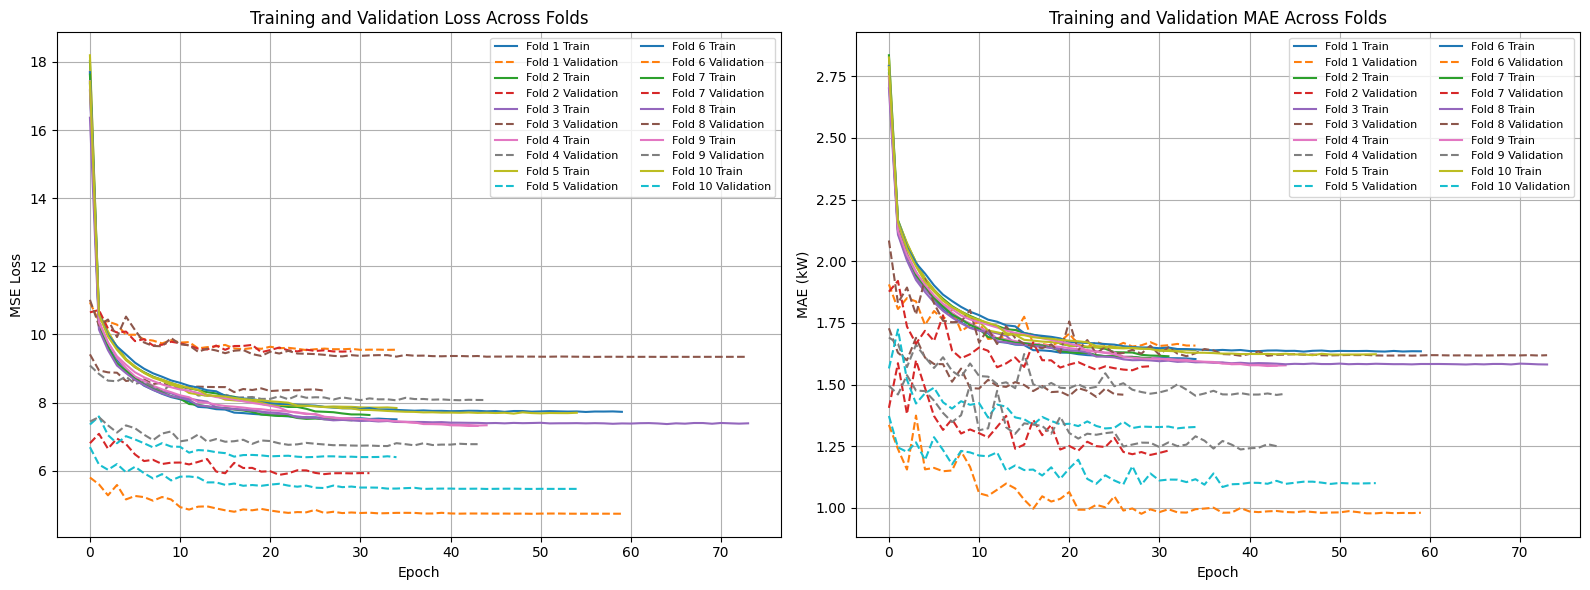

In [20]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))

# TRAINING & VALIDATION LOSS
for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss Across Folds")
axarr[0].legend(ncol=2, fontsize=8)
axarr[0].grid(True)

# TRAINING & VALIDATION MAE
for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")
    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE (kW)")
axarr[1].set_title("Training and Validation MAE Across Folds")
axarr[1].legend(ncol=2, fontsize=8)
axarr[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

print(f"{'Fold':<8} | {'Best Train RMSE (kW)':<22} | {'Best Val RMSE (kW)':<20}")
print("-" * 56)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])
    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    train_rmse = np.sqrt(best_train_loss_mse[i])
    val_rmse = np.sqrt(best_val_loss_mse[i])
    print(f"Fold {i + 1:02d}  | {train_rmse:<22.3f} | {val_rmse:<20.3f}")

print("-" * 56)
print(f"Mean Train RMSE:      {np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: {np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Fold     | Best Train RMSE (kW)   | Best Val RMSE (kW)  
--------------------------------------------------------
Fold 01  | 2.751                  | 3.089               
Fold 02  | 2.812                  | 2.425               
Fold 03  | 2.795                  | 2.883               
Fold 04  | 2.726                  | 2.840               
Fold 05  | 2.811                  | 2.530               
Fold 06  | 2.781                  | 2.177               
Fold 07  | 2.766                  | 3.079               
Fold 08  | 2.718                  | 3.057               
Fold 09  | 2.734                  | 2.593               
Fold 10  | 2.776                  | 2.338               
--------------------------------------------------------
Mean Train RMSE:      2.767 kW
Mean Validation RMSE: 2.701 kW


In [22]:
predictions = np.zeros((NUM_FOLDS, len(X_test), NUM_TARGETS), dtype=np.float32)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: {checkpoint_path}")
    fold_model = keras.models.load_model(checkpoint_path, compile=False)

    pred = fold_model.predict(X_test, batch_size=512, verbose=0)
    if pred.ndim == 1 or (pred.ndim == 2 and pred.shape[1] == 1 and NUM_TARGETS == 1):
        pred = np.reshape(pred, (-1, 1))

    predictions[fold] = pred

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average across folds
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)
print(f"\nEnsemble predictions saved. Shape: {ensemble_predictions.shape}")

Loading fold 1 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_1/best_model_repetition_1.h5
Loading fold 2 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: /content/drive/MyDrive/solar_data/model_output/LSTM_forecast_15m_1h_2017_

COMPLETE TEST SET FORECAST RESULTS (13,383 Sequences)
Horizon      | Lead Steps   | Test RMSE (kW)   | Test MAE (kW) 
--------------------------------------------------------------------
15 min       | 15           | 3.253            | 1.698         
1 hour       | 60           | 4.138            | 2.473         
--------------------------------------------------------------------
OVERALL      | All          | 3.707            | 2.072         


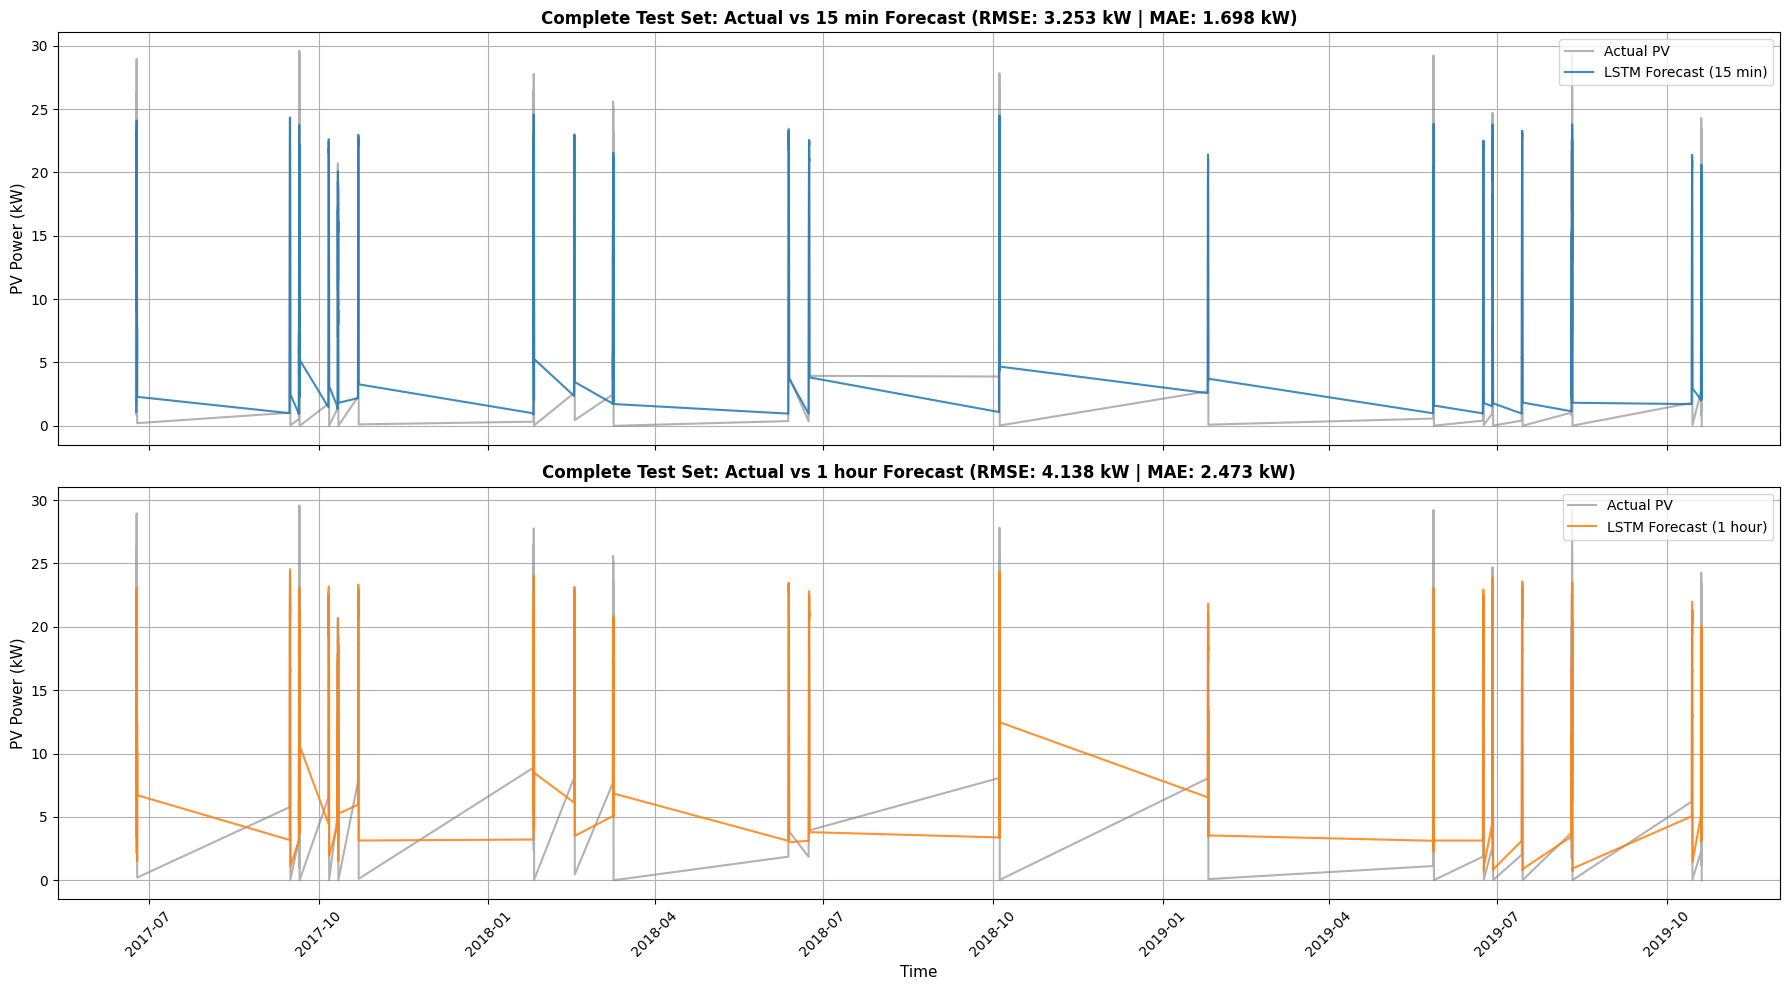

In [23]:
# TEST SET EVALUATION ACROSS ALL HORIZONS
errors = ensemble_predictions - y_test  # Shape: (N, NUM_TARGETS)

print("=" * 68)
print(f"COMPLETE TEST SET FORECAST RESULTS ({len(y_test):,} Sequences)")
print("=" * 68)
print(
    f"{'Horizon':<12} | {'Lead Steps':<12} | {'Test RMSE (kW)':<16} | {'Test MAE (kW)':<14}"
)
print("-" * 68)

horizon_metrics = {}
for k, (h_name, h_steps) in enumerate(zip(HORIZON_NAMES, FORECAST_HORIZONS)):
    h_err = errors[:, k] if errors.ndim > 1 else errors
    valid = ~np.isnan(h_err)
    h_rmse = np.sqrt(np.mean(np.square(h_err[valid])))
    h_mae = np.mean(np.abs(h_err[valid]))
    horizon_metrics[h_name] = {"rmse": h_rmse, "mae": h_mae}
    print(f"{h_name:<12} | {h_steps:<12} | {h_rmse:<16.3f} | {h_mae:<14.3f}")

print("-" * 68)
valid_all = ~np.isnan(errors)
rmse_overall = np.sqrt(np.mean(np.square(errors[valid_all])))
mae_overall = np.mean(np.abs(errors[valid_all]))
print(f"{'OVERALL':<12} | {'All':<12} | {rmse_overall:<16.3f} | {mae_overall:<14.3f}")
print("=" * 68)

# TIME-SERIES PLOTS FOR COMPLETE TEST SET
fig, axes = plt.subplots(NUM_TARGETS, 1, figsize=(18, 5 * NUM_TARGETS), sharex=True)
if NUM_TARGETS == 1:
    axes = [axes]

colors = ["#1f77b4", "#ff7f0e"]

for k, (h_name, h_color) in enumerate(zip(HORIZON_NAMES, colors)):
    ax = axes[k]
    h_times = times_test_seq[:, k] if times_test_seq.ndim > 1 else times_test_seq
    h_y_true = y_test[:, k] if y_test.ndim > 1 else y_test
    h_y_pred = (
        ensemble_predictions[:, k]
        if ensemble_predictions.ndim > 1
        else ensemble_predictions
    )
    valid_k = np.array(
        [t is not None and not np.isnan(y) for t, y in zip(h_times, h_y_true)]
    )

    ax.plot(
        h_times[valid_k],
        h_y_true[valid_k],
        color="#808080",
        alpha=0.6,
        label="Actual PV",
    )
    ax.plot(
        h_times[valid_k],
        h_y_pred[valid_k],
        color=h_color,
        alpha=0.85,
        label=f"LSTM Forecast ({h_name})",
    )
    ax.set_ylabel("PV Power (kW)", fontsize=11)
    ax.set_title(
        f"Complete Test Set: Actual vs {h_name} Forecast "
        f"(RMSE: {horizon_metrics[h_name]['rmse']:.3f} kW | MAE: {horizon_metrics[h_name]['mae']:.3f} kW)",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True)

axes[-1].set_xlabel("Time", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# SUNNY AND CLOUDY DATES FROM THE SKIPP'D PAPER
sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]
cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

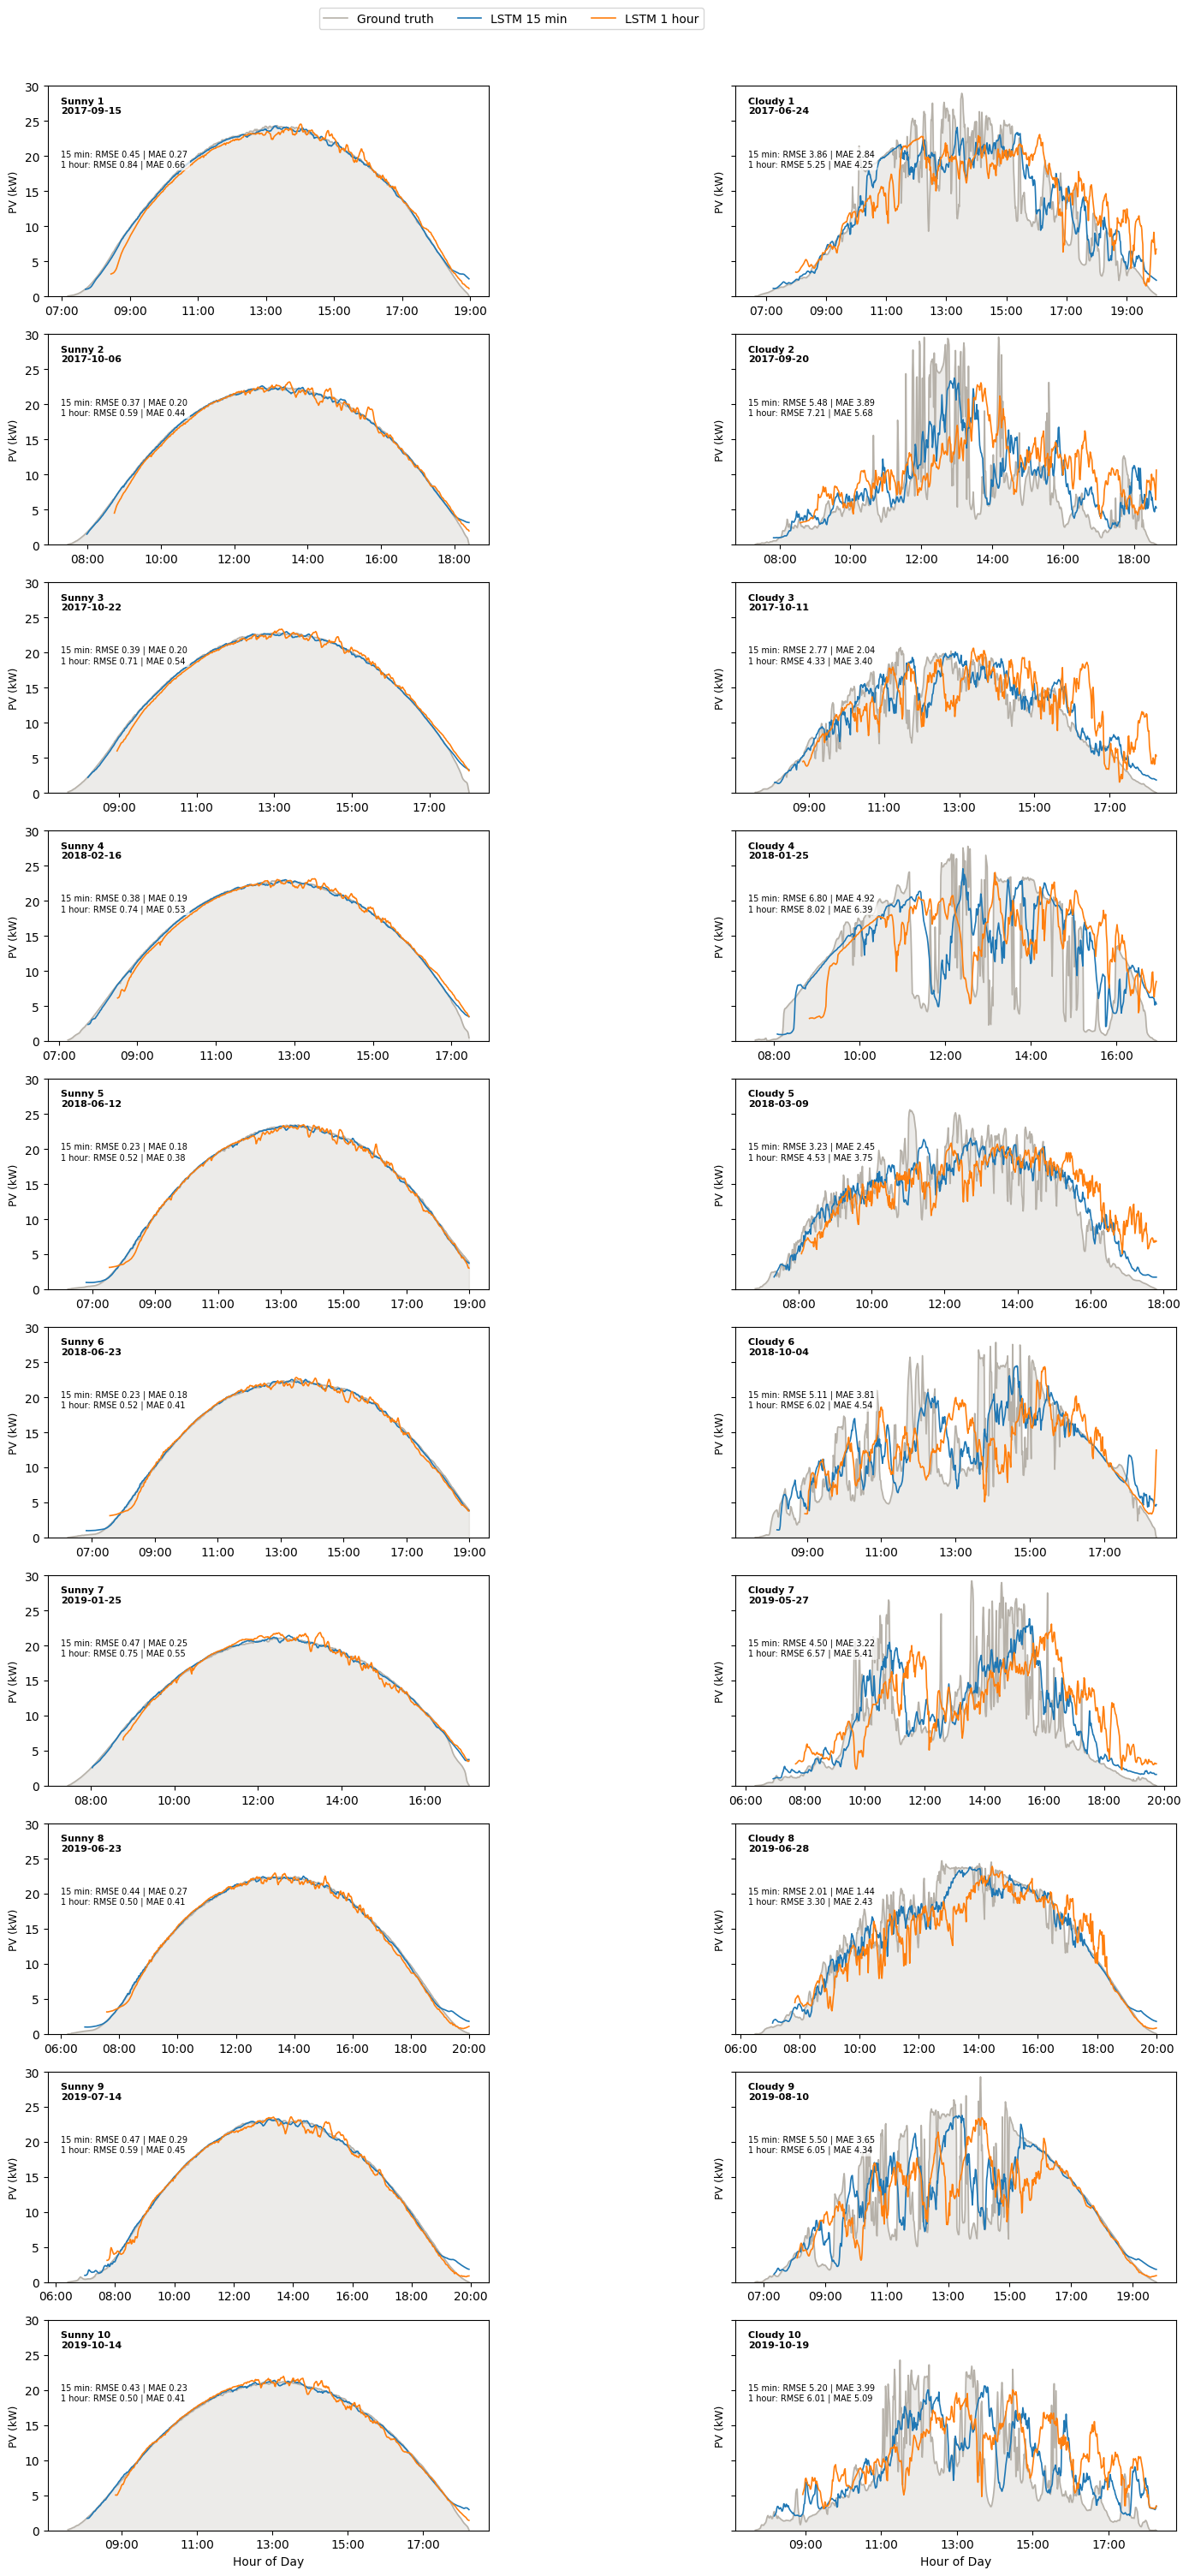

In [25]:
# Precompute full-day test dates to plot complete diurnal ground truth
dates_test_all = np.array(
    [
        (
            t.date()
            if isinstance(t, (datetime.datetime, datetime.date))
            else pd.to_datetime(t).date()
        )
        for t in times_test
    ]
)

# DAILY PROFILES EVALUATION: 10 SUNNY DAYS vs 10 CLOUDY DAYS
fig, axarr = plt.subplots(10, 2, sharex=False, sharey=True, figsize=(14, 30))

xfmt = mdates.DateFormatter("%H:%M")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
HORIZON_COLORS = [
    "#1f77b4",
    "#ff7f0e",
]  # Blue (15m), Orange (1h)


def plot_daily_forecast(ax, target_date, day_type_label, day_idx):
    date_mask = dates_test_seq == target_date
    if not np.any(date_mask):
        ax.text(0.5, 0.5, f"Date {target_date} not in test set", ha="center")
        return

    # Extract full-day ground truth from test_pv & times_test (entire sunrise to sunset)
    day_mask_full = dates_test_all == target_date
    if np.any(day_mask_full):
        times_day_full = times_test[day_mask_full]
        y_gt = test_pv[day_mask_full]
    else:
        times_day_full = (
            times_test_seq[date_mask, 0]
            if times_test_seq.ndim > 1
            else times_test_seq[date_mask]
        )
        y_gt = y_test[date_mask, 0] if y_test.ndim > 1 else y_test[date_mask]

    hours_xaxis_gt = [
        datetime.datetime.combine(
            fmt_date,
            (
                t.time()
                if isinstance(t, (datetime.datetime, datetime.time))
                else pd.to_datetime(t).time()
            ),
        )
        for t in times_day_full
    ]

    # Plot Full-Day Ground Truth
    ax.plot(
        hours_xaxis_gt,
        y_gt,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if (day_idx == 0 and day_type_label == "Sunny") else "",
    )
    ax.fill_between(hours_xaxis_gt, 0, y_gt, color=COLOR_GT, alpha=0.25)

    # Extract predictions and targets for this day
    y_true_day = y_test[date_mask]
    y_pred_day = ensemble_predictions[date_mask]

    # Plot Forecast for each horizon (15m and 1h now continue all the way to sunset!)
    metric_text_lines = [f"{day_type_label} {day_idx + 1}\n{target_date}"]
    for k, (h_name, h_color) in enumerate(zip(HORIZON_NAMES, HORIZON_COLORS)):
        times_day_hk = (
            times_test_seq[date_mask, k]
            if times_test_seq.ndim > 1
            else times_test_seq[date_mask]
        )
        # Filter valid timestamps for this horizon (omits points where target is past sunset)
        valid_mask = np.array([t is not None for t in times_day_hk])
        if not np.any(valid_mask):
            continue

        valid_times_k = times_day_hk[valid_mask]
        hours_xaxis_k = [
            datetime.datetime.combine(
                fmt_date,
                (
                    t.time()
                    if isinstance(t, (datetime.datetime, datetime.time))
                    else pd.to_datetime(t).time()
                ),
            )
            for t in valid_times_k
        ]

        y_pred_k = (
            y_pred_day[valid_mask, k] if y_pred_day.ndim > 1 else y_pred_day[valid_mask]
        )
        y_true_k = (
            y_true_day[valid_mask, k] if y_true_day.ndim > 1 else y_true_day[valid_mask]
        )

        # Filter non-NaN ground truths for metrics
        metric_valid = ~np.isnan(y_true_k)
        if np.any(metric_valid):
            d_rmse = np.sqrt(
                np.mean(np.square(y_true_k[metric_valid] - y_pred_k[metric_valid]))
            )
            d_mae = np.mean(np.abs(y_true_k[metric_valid] - y_pred_k[metric_valid]))
            metric_text_lines.append(f"{h_name}: RMSE {d_rmse:.2f} | MAE {d_mae:.2f}")

        ax.plot(
            hours_xaxis_k,
            y_pred_k,
            color=h_color,
            linewidth=1.2,
            label=(
                f"LSTM {h_name}" if (day_idx == 0 and day_type_label == "Sunny") else ""
            ),
        )

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

    # Annotations
    ax.text(
        0.03,
        0.95,
        metric_text_lines[0],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
    )
    ax.text(
        0.03,
        0.70,
        "\n".join(metric_text_lines[1:]),
        transform=ax.transAxes,
        fontsize=7,
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="none"
        ),
    )


# Plot Sunny Days (Column 0)
for i, date in enumerate(sunny_dates_test):
    plot_daily_forecast(axarr[i, 0], date, "Sunny", i)

# Plot Cloudy Days (Column 1)
for i, date in enumerate(cloudy_dates_test):
    plot_daily_forecast(axarr[i, 1], date, "Cloudy", i)

axarr[0, 0].set_ylim(0, 30)
axarr[0, 0].legend(
    bbox_to_anchor=[1.05, 1.40], loc="upper center", ncol=3, frameon=True, fontsize=10
)

axarr[-1, 0].set_xlabel("Hour of Day", fontsize=10)
axarr[-1, 1].set_xlabel("Hour of Day", fontsize=10)

plt.tight_layout()
plt.show()